In [2]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis

In [3]:
def compute_radial_spectrum(fld, dx, dy, dtype=float):
    nx, ny = fld.shape

    # Fourier wavenumbers
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K_perp = np.sqrt(KX**2 + KY**2)

    # Power spectrum density
    ff = np.abs(np.fft.ifft2(fld))**2   # use fft2, not ifft2
    P_flat = ff.ravel()
    K_flat = K_perp.ravel()

    # Radial bins
    dk = kx[1] - kx[0]
    k_bins = np.arange(0, np.max(K_flat) + dk, dk)
    nk = len(k_bins)
    P_k = np.zeros(nk, dtype=dtype)

    # Bin indices (vectorized)
    idx_float = K_flat / dk
    i1 = np.floor(idx_float).astype(int)
    i2 = i1 + 1
    w = idx_float - i1   # weight to upper bin

    # Accumulate into bins
    for i in range(len(K_flat)):
        if i1[i] >= 0 and i2[i] < nk:
            P_k[i1[i]] += P_flat[i] * (1 - w[i])
            P_k[i2[i]] += P_flat[i] * w[i]

    # Pack into recarray
    tags = ['kk', 'sp']
    sps = np.recarray((nk,), dtype=[(t, dtype) for t in tags])
    sps['kk'] = k_bins
    sps['sp'] = P_k / dk

    return sps

def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

In [4]:
# List of simulation directories

dx = 0.0625
dy = 0.0625

In [5]:
# Plotting Power Spectrum at reconnection time

base_path = "/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.25/beta_e_0.25"

max_turbulence_time = 253

File_Bx = f"{base_path}/Bx_ApJ_t{max_turbulence_time}.h5"
File_By = f"{base_path}/By_ApJ_t{max_turbulence_time}.h5"
File_Bz = f"{base_path}/Bz_ApJ_t{max_turbulence_time}.h5"
File_Dn = f"{base_path}/Dn1_ApJ_t{max_turbulence_time}.h5"


with h5py.File(File_Bx, 'r') as fBx, \
         h5py.File(File_By, 'r') as fBy, \
         h5py.File(File_Bz, 'r') as fBz:

        data_Bx = fBx['DS1'][:].T
        data_By = fBy['DS1'][:].T
        data_Bz = fBz['DS1'][:].T

with h5py.File(File_Dn, 'r') as fDn:
    data_Dn = fDn['DS1'][:].T

data_Jx =  partial_y_fft(data_Bz, dx)
data_Jy = -partial_x_fft(data_Bz, dx)
data_Jz =  partial_x_fft(data_By, dx) - partial_y_fft(data_Bx, dx)

# Compute radial spectra
spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
spectrum_By = compute_radial_spectrum(data_By, dx, dy)
spectrum_Bz = compute_radial_spectrum(data_Bz, dx, dy)

spectrum_Jx = compute_radial_spectrum(data_Jx, dx, dy)
spectrum_Jy = compute_radial_spectrum(data_Jy, dx, dy)
spectrum_Jz = compute_radial_spectrum(data_Jz, dx, dy)


spectrum_B = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
spectrum_B.kk = spectrum_Bx.kk
spectrum_B.sp = spectrum_Bx.sp + spectrum_By.sp + spectrum_Bz.sp

spectrum_J = np.recarray(spectrum_Jx.shape, dtype=spectrum_Jx.dtype)
spectrum_J.kk = spectrum_Jx.kk
spectrum_J.sp = spectrum_Jx.sp + spectrum_Jy.sp + spectrum_Jz.sp

spectrum_D = compute_radial_spectrum(data_Dn, dx, dy)

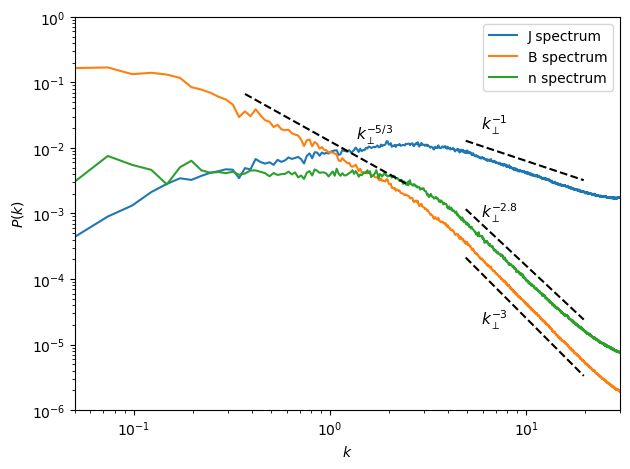

In [23]:
# Plot
plt.loglog(
    spectrum_J.kk,
    spectrum_J.sp,
    label="J spectrum"
)

plt.loglog(
    spectrum_B.kk,
    spectrum_B.sp,
    label="B spectrum"
)

plt.loglog(
    spectrum_D.kk,
    spectrum_D.sp,
    label="n spectrum"
)

# Add slope lines
k_range_1 = spectrum_B.kk[200:800]
k_range_2 = spectrum_B.kk[200:800]
k_range_3 = spectrum_B.kk[15:100]
k_range_4 = spectrum_B.kk[200:800]

slope_line_1 = 10**(-1.6) * k_range_1**(-3)
slope_line_2 = 10**(-1.2) * k_range_2**(-1)
slope_line_3 = 10**(-1.9) * k_range_3**(-5/3)
slope_line_4 = 10**(-1.0) * k_range_4**(-2.8)

plt.loglog(k_range_1, slope_line_1, 'k--')
plt.loglog(k_range_2, slope_line_2, 'k--')
plt.loglog(k_range_3, slope_line_3, 'k--')
plt.loglog(k_range_4, slope_line_4, 'k--')

# Inline slope labels
plt.text(k_range_1[40], slope_line_1[4]*.1, r'$k_\perp^{-3}$', fontsize=11)
plt.text(k_range_2[40], slope_line_2[4]*1.5, r'$k_\perp^{-1}$', fontsize=11)
plt.text(k_range_3[40], slope_line_3[4]*0.3, r'$k_\perp^{-5/3}$', fontsize=11)
plt.text(k_range_4[40], slope_line_4[4]*.8, r'$k_\perp^{-2.8}$', fontsize=11)

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.xlim(5e-2, 30)
plt.ylim(1e-6, 1)

plt.legend()  # <-- this is the key line

plt.tight_layout()
plt.savefig("JBD_Spectrum", dpi=300)
plt.show()